# Q Actor-Critic (QAC) for Acrobot-v1

## Goal and method
This notebook trains a neural Q Actor-Critic agent to swing Acrobot's free end above the goal height. The actor outputs categorical action logits for the three torque actions; the critic estimates $Q_\phi(s,a)$ for every action. During training, the action is sampled from the actor and the critic uses the on-policy one-step SARSA target:

$$y_t = r_t + \gamma Q_\phi(s_{t+1}, a_{t+1})$$

where $a_{t+1} \sim \pi_\theta(\cdot \mid s_{t+1})$. The critic minimizes $(y_t-Q_\phi(s_t,a_t))^2$. The actor maximizes the critic estimate through the policy-gradient objective $\log \pi_\theta(a_t\mid s_t)Q_\phi(s_t,a_t)$ with an entropy bonus for exploration.

## Experimental protocol
The run uses a fixed seed (42), 1,000 training episodes, a 500-step cap, $\gamma=0.99$, two 64-unit Tanh hidden layers, actor learning rate $5\times10^{-4}$, critic learning rate $10^{-3}$, and entropy coefficient $0.01$. Greedy checkpoint evaluations occur every 100 episodes. The checkpoint policy with the highest success rate (then highest mean return on a tie) is retained and is the policy used for the final 100-episode evaluation.

## Reported metrics
Training return and its 50-episode moving average; episode length; greedy checkpoint and final success rates; final greedy mean and standard deviation of return; final mean episode length and steps to goal; sample-efficiency threshold; critic TD loss; mean absolute TD error; policy entropy; and wall-clock training time.

In [ ]:
import copy
import os
import time

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn, optim
from torch.distributions import Categorical

DEVICE = torch.device("cpu")
CONFIG = {
    "seed": 42, "torch_threads": 1, "hidden_size": 64, "actor_lr": 5e-4, "critic_lr": 1e-3,
    "gamma": 0.99, "entropy_coef": 0.01, "episodes": 1_000, "max_steps": 500,
    "eval_interval": 100, "eval_episodes": 50, "final_eval_episodes": 100,
    "ma_window": 50, "efficiency_threshold": -300.0,
}
torch.set_num_threads(CONFIG["torch_threads"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])
print(f"PyTorch {torch.__version__} | Gymnasium {gym.__version__} | {DEVICE}")

PyTorch 2.13.0+cpu | Gymnasium 1.3.0 | cpu


In [ ]:
class MLP(nn.Module):
    """Simple 2-hidden-layer network shared by both the actor and the critic."""

    def __init__(self, state_dim, output_dim, hidden_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, output_dim),
        )

    def forward(self, state):
        return self.net(state)


def build_agent(env, cfg):
    """Create the actor (outputs action logits) and critic (outputs Q(s, .)) plus their optimizers."""
    state_dim, action_dim = env.observation_space.shape[0], env.action_space.n
    actor = MLP(state_dim, action_dim, cfg["hidden_size"]).to(DEVICE)
    critic = MLP(state_dim, action_dim, cfg["hidden_size"]).to(DEVICE)
    return actor, critic, optim.Adam(actor.parameters(), lr=cfg["actor_lr"]), optim.Adam(critic.parameters(), lr=cfg["critic_lr"])


def run_episode(env, actor, critic, actor_opt=None, critic_opt=None, cfg=None, greedy=False):
    """Roll out one episode.

    greedy=False (training): samples actions from pi_theta(.|s) and performs an
    online QAC update after every step (SARSA-style critic target + policy-gradient
    actor update, scored by the critic's Q(s,a)).
    greedy=True (evaluation): picks argmax pi_theta(.|s), no learning, used for
    checkpoint/final evaluation.
    """
    state, _ = env.reset()
    state = torch.as_tensor(state, dtype=torch.float32, device=DEVICE)
    reward_sum = loss_sum = td_sum = entropy_sum = 0.0
    updates = 0

    for length in range(1, cfg["max_steps"] + 1):
        if greedy:
            # Evaluation: no gradient tracking needed, just pick the best action.
            with torch.inference_mode():
                action = int(actor(state).argmax().item())
        else:
            # Training: sample stochastically from the actor's categorical policy.
            distribution = Categorical(logits=actor(state))
            action_tensor = distribution.sample()
            action = int(action_tensor.item())

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_state = torch.as_tensor(next_state, dtype=torch.float32, device=DEVICE)
        reward_sum += reward

        if not greedy:
            log_prob, entropy = distribution.log_prob(action_tensor), distribution.entropy()
            with torch.no_grad():
                # SARSA-style TD target: bootstrap with Q(s', a') where a' ~ pi(.|s'),
                # or just the reward if the episode ended.
                target = torch.as_tensor(reward, dtype=torch.float32, device=DEVICE) if done else reward + cfg["gamma"] * critic(next_state)[Categorical(logits=actor(next_state)).sample()]
            q_sa = critic(state)[action]
            td_error = target - q_sa

            # --- Critic update: minimize TD error^2 ---
            critic_loss = td_error.square()
            critic_opt.zero_grad()
            critic_loss.backward()
            critic_opt.step()

            # --- Actor update: policy gradient scored by the critic's Q(s,a),
            # plus an entropy bonus to encourage exploration. ---
            actor_loss = -(log_prob * q_sa.detach()) - cfg["entropy_coef"] * entropy
            actor_opt.zero_grad()
            actor_loss.backward()
            actor_opt.step()

            # Track per-step diagnostics to average over the episode.
            loss_sum += critic_loss.item()
            td_sum += td_error.abs().item()
            entropy_sum += entropy.item()
            updates += 1

        if done:
            break
        state = next_state

    return {"reward": reward_sum, "length": length, "success": int(terminated),
            "critic_loss": loss_sum / updates if updates else np.nan,
            "mean_abs_td_error": td_sum / updates if updates else np.nan,
            "entropy": entropy_sum / updates if updates else np.nan}


def evaluate(env, actor, critic, cfg, episodes):
    """Run `episodes` greedy (no-learning) rollouts and collect their rewards/lengths/successes."""
    results = [run_episode(env, actor, critic, cfg=cfg, greedy=True) for _ in range(episodes)]
    return {key: np.array([row[key] for row in results]) for key in ("reward", "length", "success")}

In [ ]:
def train(env, eval_env, actor, critic, actor_opt, critic_opt, cfg):
    """Train online and retain the highest-performing greedy checkpoint policy."""
    history = {key: [] for key in ("reward", "length", "success", "critic_loss", "mean_abs_td_error", "entropy")}
    checkpoints = []
    best_checkpoint = {"episode": 0, "success_rate_pct": -np.inf, "mean_return": -np.inf,
                       "actor_state": copy.deepcopy(actor.state_dict())}
    start = time.perf_counter()
    for episode in range(1, cfg["episodes"] + 1):
        result = run_episode(env, actor, critic, actor_opt, critic_opt, cfg)
        for key in history:
            history[key].append(result[key])

        if episode % cfg["eval_interval"] == 0:
            evaluation = evaluate(eval_env, actor, critic, cfg, cfg["eval_episodes"])
            rate = 100 * evaluation["success"].mean()
            mean_return = evaluation["reward"].mean()
            checkpoints.append((episode, rate, mean_return))
            if (rate, mean_return) > (best_checkpoint["success_rate_pct"], best_checkpoint["mean_return"]):
                best_checkpoint = {"episode": episode, "success_rate_pct": rate, "mean_return": mean_return,
                                   "actor_state": copy.deepcopy(actor.state_dict())}
            print(f"Episode {episode:4d} | MA return: {np.mean(history['reward'][-cfg['ma_window']:]):7.1f} | Eval success: {rate:5.1f}%")
    history["training_time_sec"] = time.perf_counter() - start
    history["checkpoints"] = checkpoints
    history["best_checkpoint"] = best_checkpoint
    return history


def summarize(history, final_eval, cfg):
    """Reduce the selected-policy evaluation and training history into report metrics."""
    rewards = np.asarray(history["reward"])
    moving_average = np.convolve(rewards, np.ones(cfg["ma_window"])/cfg["ma_window"], mode="valid")
    crossing = np.flatnonzero(moving_average >= cfg["efficiency_threshold"])
    successful_lengths = final_eval["length"][final_eval["success"].astype(bool)]
    selected = history["best_checkpoint"]
    return {
        "training_episodes": cfg["episodes"], "selected_checkpoint_episode": selected["episode"],
        "selected_checkpoint_success_rate_pct": selected["success_rate_pct"],
        "best_ma_return": moving_average.max(),
        "sample_efficiency_episode": int(crossing[0] + cfg["ma_window"]) if crossing.size else np.nan,
        "final_eval_mean_return": final_eval["reward"].mean(), "final_eval_std_return": final_eval["reward"].std(),
        "final_eval_success_rate_pct": 100 * final_eval["success"].mean(),
        "final_eval_mean_length": final_eval["length"].mean(),
        "mean_steps_to_goal": successful_lengths.mean() if successful_lengths.size else np.nan,
        "training_time_sec": history["training_time_sec"],
        "final_critic_td_loss": np.nanmean(history["critic_loss"][-100:]),
        "final_mean_abs_td_error": np.nanmean(history["mean_abs_td_error"][-100:]),
        "final_policy_entropy": np.nanmean(history["entropy"][-100:]),
    }


def plot_results(history, cfg, output_dir):
    """Render a 2x2 diagnostic figure: training return, episode length, checkpoint
    success rate, and critic loss/TD-error, then save it to disk."""
    os.makedirs(output_dir, exist_ok=True)
    rewards = np.asarray(history["reward"])
    figure, axes = plt.subplots(2, 2, figsize=(12, 7))
    window = cfg["ma_window"]

    # Top-left: raw return per episode plus its moving average.
    axes[0, 0].plot(rewards, alpha=.25, label="return")
    axes[0, 0].plot(np.arange(window - 1, len(rewards)), np.convolve(rewards, np.ones(window)/window, mode="valid"), label=f"{window}-episode MA")
    axes[0, 0].set(title="Training return", xlabel="Episode", ylabel="Return")

    # Top-right: episode length (steps until termination/truncation).
    axes[0, 1].plot(history["length"], color="darkorange")
    axes[0, 1].set(title="Episode length", xlabel="Episode", ylabel="Steps")

    # Bottom-left: greedy success rate measured at each checkpoint evaluation.
    checkpoint_array = np.asarray(history["checkpoints"])
    axes[1, 0].plot(checkpoint_array[:, 0], checkpoint_array[:, 1], marker="o", color="seagreen")
    axes[1, 0].set(title="Greedy checkpoint success", xlabel="Training episode", ylabel="Success (%)", ylim=(0, 105))

    # Bottom-right: critic learning-stability diagnostics.
    axes[1, 1].plot(history["critic_loss"], label="TD loss")
    axes[1, 1].plot(history["mean_abs_td_error"], label="|TD error|")
    axes[1, 1].set(title="Critic diagnostics", xlabel="Episode")

    for axis in axes.flat:
        axis.legend() if axis.get_legend_handles_labels()[0] else None
    figure.tight_layout()
    figure.savefig(os.path.join(output_dir, "qac_metrics_optimized.png"), dpi=150)
    plt.show()

Episode  100 | MA return:  -103.3 | Eval success:  80.0%
Episode  200 | MA return:  -142.9 | Eval success: 100.0%
Episode  300 | MA return:  -500.0 | Eval success:   0.0%
Episode  400 | MA return:  -363.0 | Eval success:  90.0%
Episode  500 | MA return:  -126.5 | Eval success:  60.0%
Episode  600 | MA return:  -166.2 | Eval success: 100.0%
Episode  700 | MA return:  -159.6 | Eval success: 100.0%
Episode  800 | MA return:  -150.3 | Eval success: 100.0%
Episode  900 | MA return:  -119.0 | Eval success:  40.0%
Episode 1000 | MA return:  -172.3 | Eval success:  60.0%


,value
training_episodes,1000.00
best_ma_return,-87.84
sample_efficiency_episode,61.00
final_eval_mean_return,-286.06
final_eval_std_return,197.75
final_eval_success_rate_pct,54.00
final_eval_mean_length,286.60
mean_steps_to_goal,104.81
training_time_sec,1917.65
final_critic_td_loss,8.97


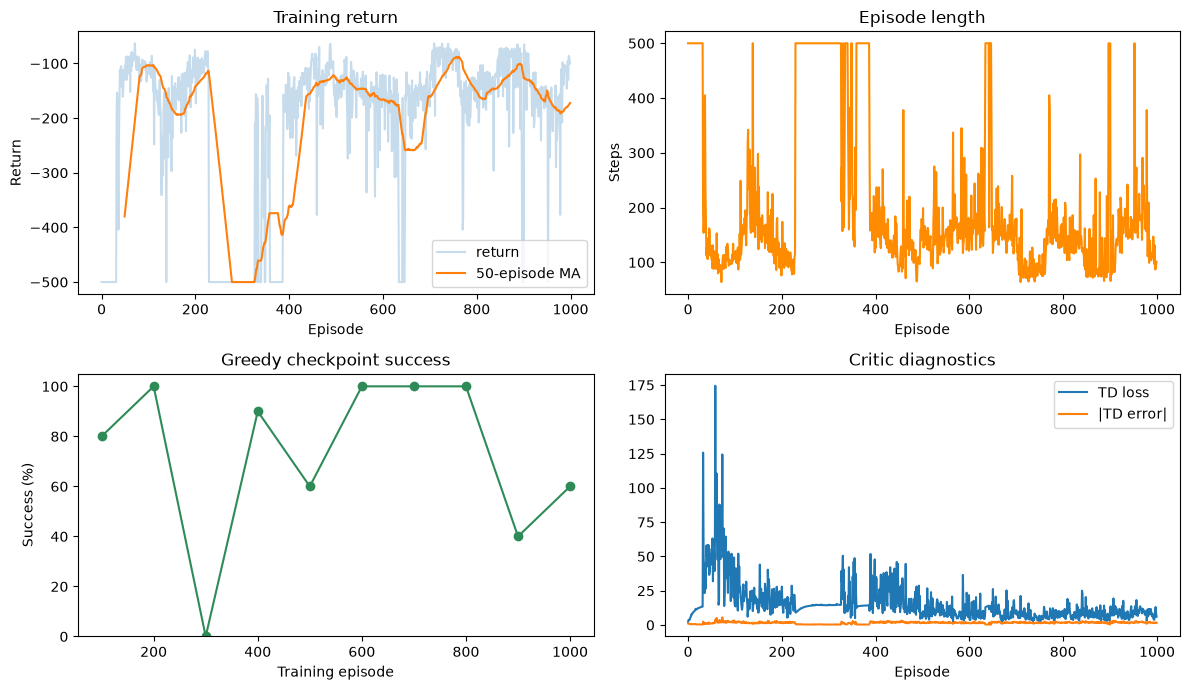

In [ ]:
# Create separate train/eval envs (different seed) so checkpoint evaluation
# doesn't perturb the training environment's RNG stream.
env, eval_env = gym.make("Acrobot-v1"), gym.make("Acrobot-v1")
env.reset(seed=CONFIG["seed"])
eval_env.reset(seed=CONFIG["seed"] + 1)
actor, critic, actor_opt, critic_opt = build_agent(env, CONFIG)

# Train, restore the objectively best checkpoint policy, then evaluate that policy.
history = train(env, eval_env, actor, critic, actor_opt, critic_opt, CONFIG)
actor.load_state_dict(history["best_checkpoint"]["actor_state"])
final_eval = evaluate(eval_env, actor, critic, CONFIG, CONFIG["final_eval_episodes"])
metrics = summarize(history, final_eval, CONFIG)

# Persist per-episode history and the summary metrics table as CSVs alongside the notebook.
output_dir = os.path.dirname(os.path.abspath("Q_Actor_Critic_Acrobot_2.ipynb")) or "."
episode_history = {key: values for key, values in history.items() if isinstance(values, list) and key != "checkpoints"}
pd.DataFrame(episode_history).to_csv(os.path.join(output_dir, "results_qac_optimized.csv"), index_label="episode")
pd.DataFrame([metrics]).round(4).to_csv(os.path.join(output_dir, "summary_qac_optimized.csv"), index=False)

# Display the metrics table and diagnostic plots inline, then clean up the envs.
display(pd.DataFrame([metrics]).round(2).T.rename(columns={0: "value"}))
plot_results(history, CONFIG, os.path.join(output_dir, "figures"))
env.close()
eval_env.close()